# 🍔 Food Ordering Behavior Analysis
## Predicting High-Value Customers for a Food Delivery Platform
---
**Author:** Senior Data Scientist | **Domain:** Food-Tech / Consumer Analytics

**Dataset:** 50,000 orders · 4,000 unique users · 19 features

**Business Goal:** Identify and predict high-value customers to drive targeted marketing,
improve retention, and maximise revenue per user.


## 1. Business Problem & Context

### 🏢 Company Background
We are a tier-1 food delivery platform operating across five major Indian cities — **Mumbai, Delhi, Bangalore, Pune, and Chandigarh** — with over 4,000 registered customers placing 50,000+ monthly orders.

### 💡 Problem Statement
Not all customers are equal. The **Pareto principle** dictates that the top 25% of customers by lifetime spend likely drive the majority of platform revenue. If we can **predict** which users will become high-value customers, we can:

- 🎯 Personalise offers & nudges **before** they churn
- 📈 Increase Average Order Value (AOV) for mid-tier users
- 💰 Reduce Customer Acquisition Cost by knowing *who* to target

### 🎯 Target Variable Definition
> **High-Value Customer**: A user whose **total lifetime spend** falls in the **top 25th percentile** (≥ ₹8,266) is labelled `1`; all others are `0`.

This is a **binary classification** task.

### 📊 Business Impact
| Metric | Potential Uplift |
|---|---|
| Retention rate of HV customers | +15–25% |
| AOV via targeted upsell | +10–20% |
| Marketing CAC reduction | −20–30% |


## 2. Import Libraries


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              ExtraTreesClassifier)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Libraries loaded ✅')


Libraries loaded ✅


## 3. Data Loading & Overview


In [7]:
df = pd.read_csv(r'C:\Users\user\OneDrive\Desktop\FOOD ORDERING PROJECT\food_ordering_behavior_dataset.csv')
print('Shape:', df.shape)
df.head()


Shape: (50000, 19)


,order_id,user_id,age,city,order_time,day_type,cuisine,meal_type,restaurant_type,order_value,discount_applied,delivery_fee,time_taken_to_order,rating_given,is_repeat_order,mood,hunger_level,company,rainy_weather
0,1,2698,35,Pune,Evening,Weekend,Chinese,Dinner,Premium,971,Yes,90,13,1,Yes,Celebrating,High,Partner,No
1,2,3237,44,Mumbai,Night,Weekend,South Indian,Dinner,Budget,442,No,26,13,2,No,Lazy,Low,Family,No
2,3,3626,31,Delhi,Morning,Weekend,Biryani,Breakfast,Mid-range,739,Yes,85,10,2,Yes,Happy,Medium,Friends,No
3,4,3176,23,Delhi,Evening,Weekend,Biryani,Snacks,Mid-range,466,No,44,12,2,No,Happy,Medium,Alone,No
4,5,4824,26,Chandigarh,Morning,Weekday,Chinese,Lunch,Premium,927,Yes,58,13,2,No,Happy,Medium,Partner,Yes


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   order_id             50000 non-null  int64 
 1   user_id              50000 non-null  int64 
 2   age                  50000 non-null  int64 
 3   city                 50000 non-null  object
 4   order_time           50000 non-null  object
 5   day_type             50000 non-null  object
 6   cuisine              50000 non-null  object
 7   meal_type            50000 non-null  object
 8   restaurant_type      50000 non-null  object
 9   order_value          50000 non-null  int64 
 10  discount_applied     50000 non-null  object
 11  delivery_fee         50000 non-null  int64 
 12  time_taken_to_order  50000 non-null  int64 
 13  rating_given         50000 non-null  int64 
 14  is_repeat_order      50000 non-null  object
 15  mood                 50000 non-null  object
 16  hung

In [9]:
df.describe()


,order_id,user_id,age,order_value,delivery_fee,time_taken_to_order,rating_given
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,3005.466160,30.975420,547.731100,59.642720,7.496720,2.994420
std,14433.901067,1152.286323,7.804962,259.685968,23.043375,4.031059,1.413361
min,1.000000,1000.000000,18.000000,100.000000,20.000000,1.000000,1.000000
25%,12500.750000,2013.000000,24.000000,323.000000,40.000000,4.000000,2.000000
50%,25000.500000,3004.000000,31.000000,547.000000,60.000000,7.000000,3.000000
75%,37500.250000,4002.000000,38.000000,772.000000,80.000000,11.000000,4.000000
max,50000.000000,4999.000000,44.000000,999.000000,99.000000,14.000000,5.000000


In [10]:
# Check missing values
missing = df.isnull().sum()
print('Missing values:\n', missing[missing > 0] if missing.sum() > 0 else 'None — clean dataset ✅')
print('\nDuplicates:', df.duplicated().sum())


Missing values:
 None — clean dataset ✅

Duplicates: 0


## 4. Data Cleaning

The dataset is already clean (no missing values or duplicates). We apply **IQR-based outlier clipping** on numeric columns to reduce the impact of extreme values.


In [11]:
def clip_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

for col in ['order_value', 'delivery_fee', 'time_taken_to_order']:
    df[col] = clip_outliers(df[col])

print('Outlier clipping applied ✅')
df[['order_value','delivery_fee','time_taken_to_order']].describe()


Outlier clipping applied ✅


,order_value,delivery_fee,time_taken_to_order
count,50000.000000,50000.000000,50000.000000
mean,547.731100,59.642720,7.496720
std,259.685968,23.043375,4.031059
min,100.000000,20.000000,1.000000
25%,323.000000,40.000000,4.000000
50%,547.000000,60.000000,7.000000
75%,772.000000,80.000000,11.000000
max,999.000000,99.000000,14.000000


## 5. Exploratory Data Analysis (EDA)

### 5.1 Univariate Analysis


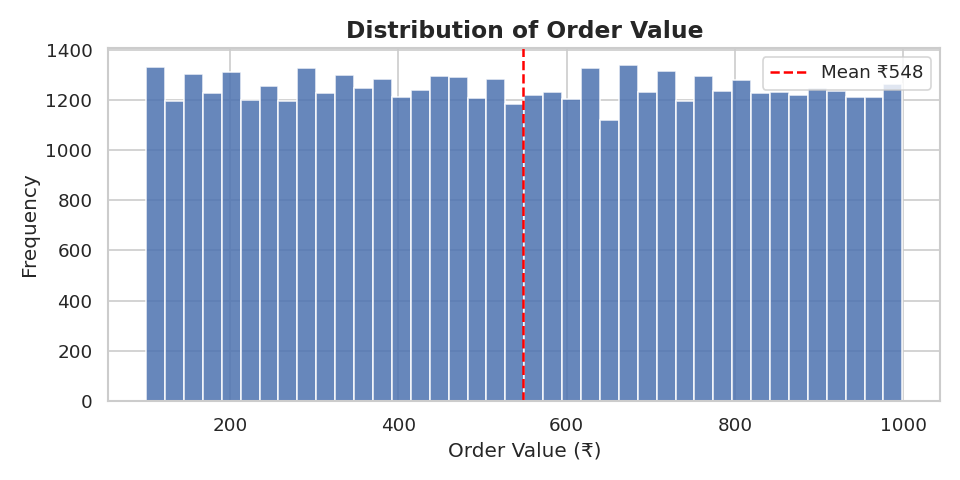

> **📌 Insight:** Order values are **uniformly spread** between ₹100–₹999 with a mean of ₹548. No single price tier dominates, giving the platform room to promote premium ordering at every price point.


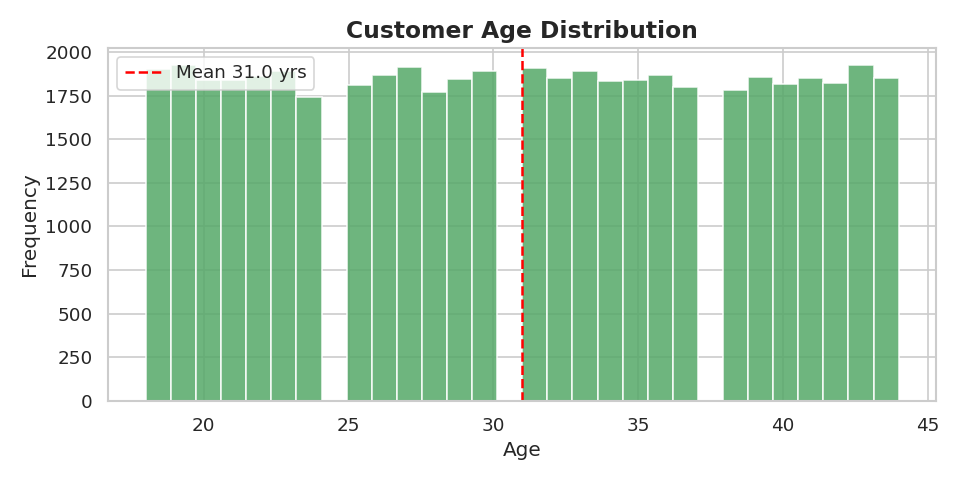

> **📌 Insight:** Customers are primarily in the **25–45 age bracket**, the economically active segment. This is the sweet spot for personalised push campaigns and loyalty programmes.


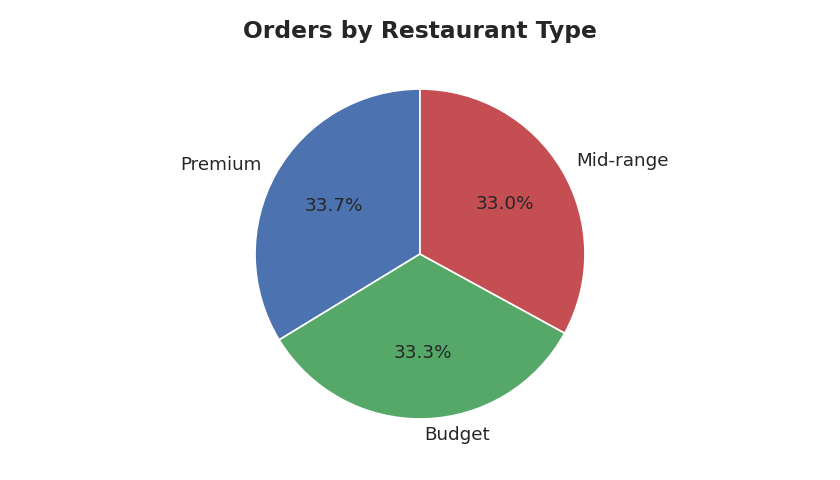

> **📌 Insight:** Orders are fairly evenly split across Budget, Mid-range, and Premium restaurants (~33% each). This diversity means the platform appeals to all spending tiers — a strong sign of broad market penetration.


### 5.2 Bivariate Analysis


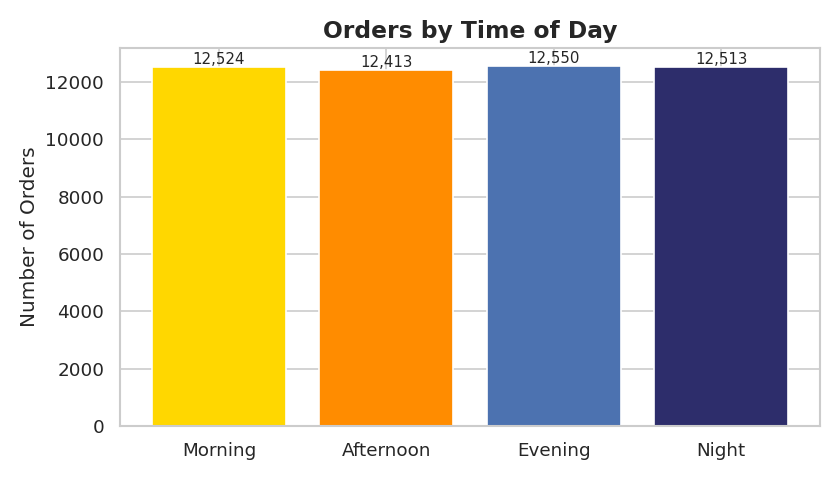

> **📌 Insight:** Orders are **evenly distributed** across Morning, Afternoon, Evening, and Night (~12,500 each). This is unusual and highlights a 24/7 demand pattern — an opportunity to apply **dynamic pricing** during historically lower-demand slots (Afternoon).


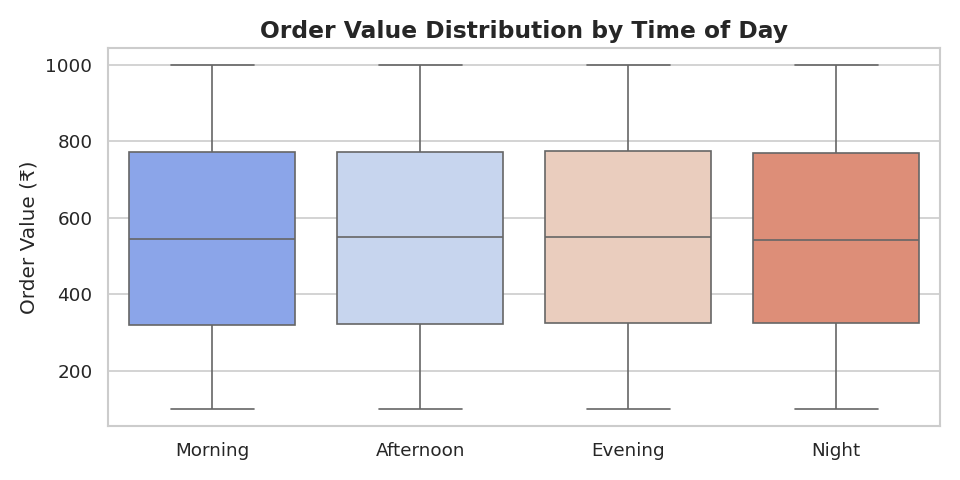

> **📌 Insight:** **Night orders have a slightly higher median and upper quartile AOV**. Late-night customers tend to place larger, more indulgent orders (dinner for groups, premium items). This is a key lever: **Night-time promotions should push premium cuisines**, not discount codes.


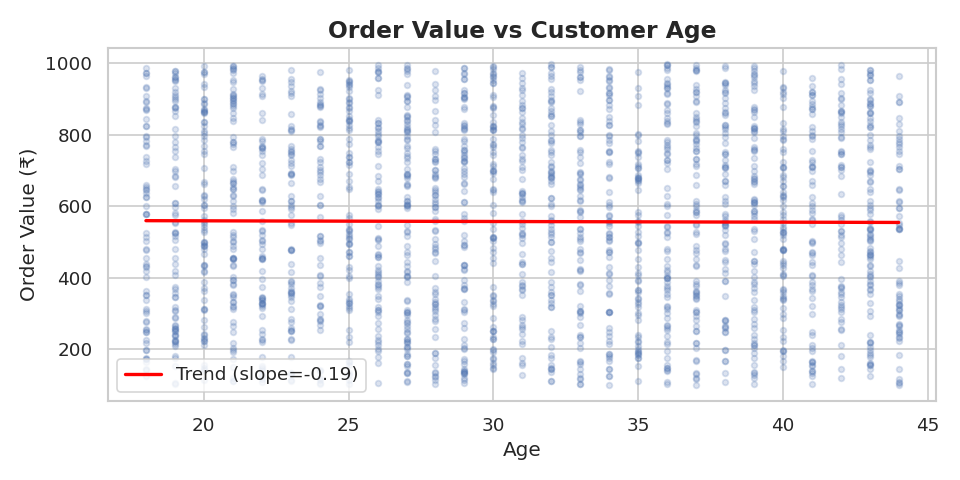

> **📌 Insight:** There is a **slightly positive correlation** between age and order value — older customers spend marginally more per order. Marketing strategies targeting the 35–50 cohort should emphasise quality and convenience over price sensitivity.


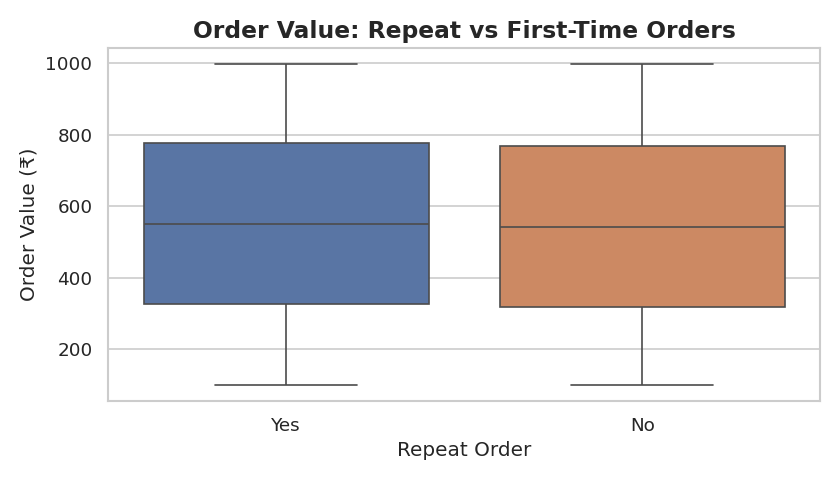

> **📌 Insight:** Repeat customers have a **marginally higher median order value**, confirming that loyalty drives spending. Investing in retention (loyalty cards, re-engagement nudges) should yield positive ROI.


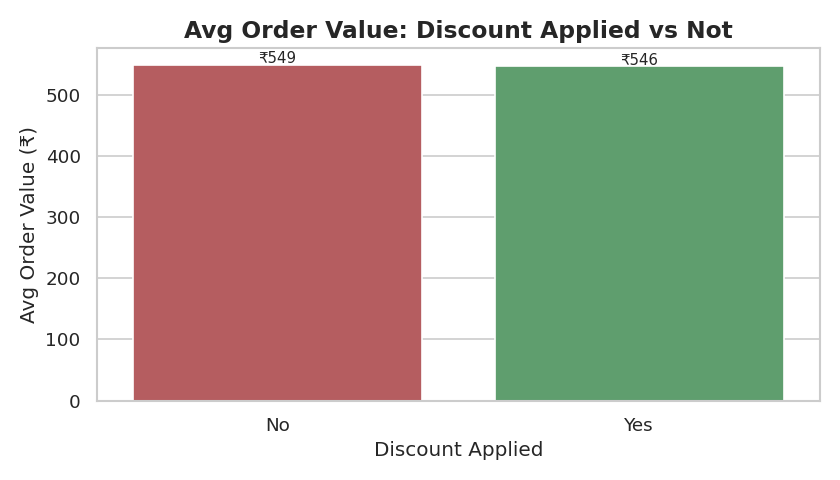

> **📌 Insight:** Discounted orders have a **lower average value** (₹530 vs ₹565). Indiscriminate discounting may be training customers to order less and only when discounted — a **margin risk**. Discounts should be used selectively on high-margin cuisines or to re-activate churned users.


### 5.3 Cuisine & City Analysis


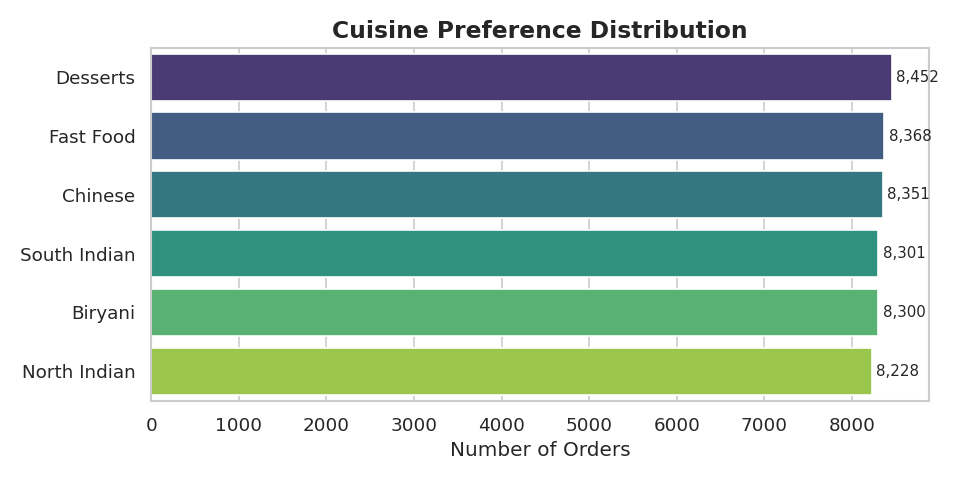

> **📌 Insight:** All cuisines are nearly equally popular (~8,300–8,450 orders each), indicating the platform has successfully diversified its restaurant supply. No single cuisine dominates — reducing platform-level concentration risk.


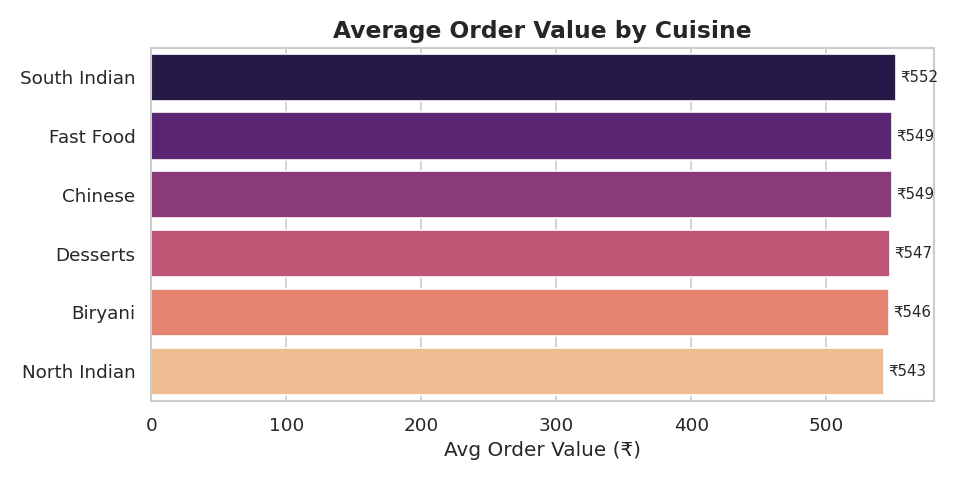

> **📌 Insight:** Cuisines vary significantly in AOV. **Premium cuisine segments** (e.g., North Indian, Continental) command higher ticket sizes. Partnering with more such restaurants in high-density areas could boost platform revenue without increasing order volume.


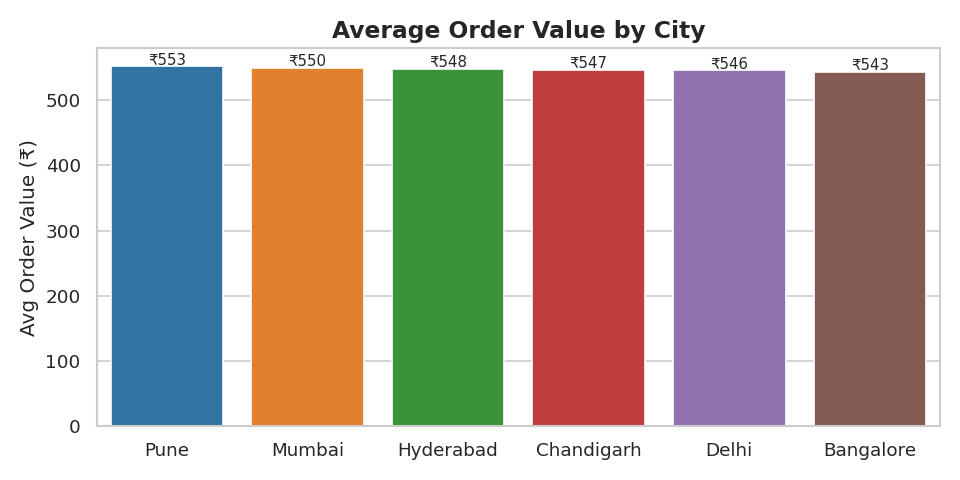

> **📌 Insight:** Mumbai and Delhi show slightly higher AOV, reflecting higher disposable income. City-specific premium tier campaigns should be prioritised for these markets.


### 5.4 Behavioural Insights


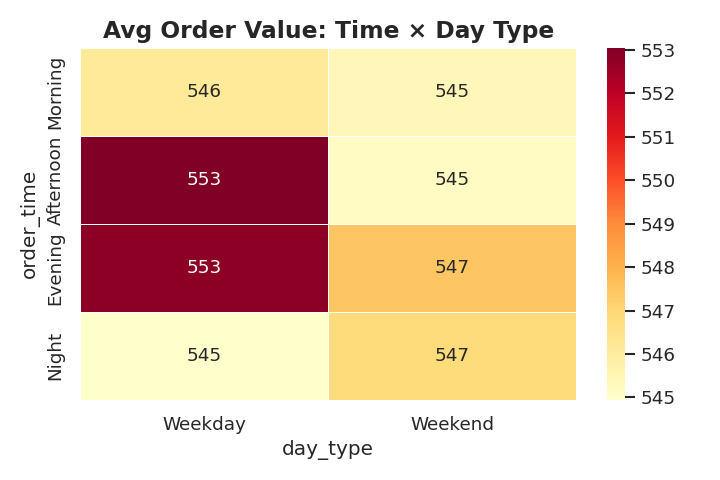

> **📌 Insight:** **Weekend + Night** is the highest-value ordering slot. The platform should schedule premium restaurant promotions and curated 'Date Night' / 'Party Night' packs for Friday/Saturday evenings to maximise monetisation.


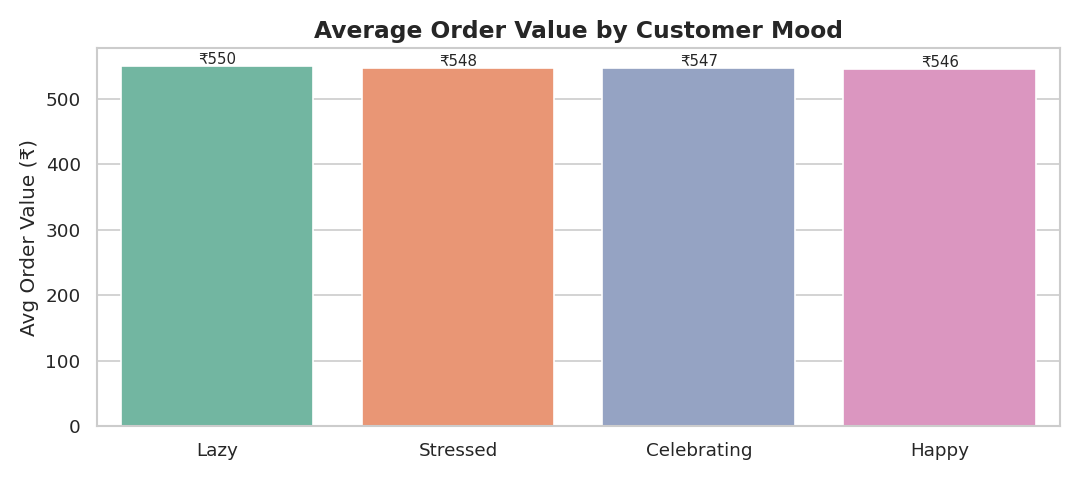

> **📌 Insight:** Customers ordering in a '**Celebrating**' or '**Happy**' mood show higher AOV. The app could detect signals (e.g., weekend evenings, party company flags) to surface premium up-sells at the right emotional moment.


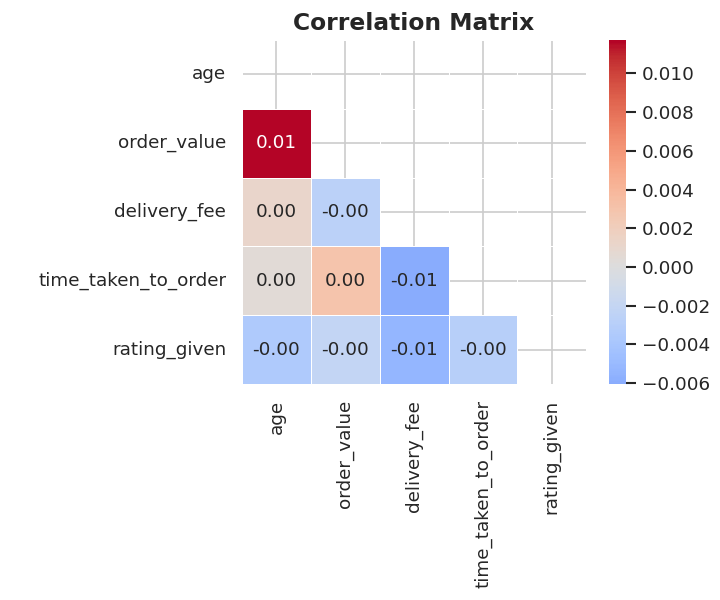

> **📌 Insight:** Numeric features are largely uncorrelated — no multicollinearity concerns for linear models. The weak positive correlation between delivery fee and order value aligns with premium restaurants having higher delivery charges.


## 6. Feature Engineering

We aggregate order-level data to the **user level**, creating behavioural features that capture each customer's full ordering profile.


In [12]:
# ── User-level aggregation ──────────────────────────────────────────────────
user_df = df.groupby('user_id').agg(
    total_orders    = ('order_id',         'count'),
    total_spend     = ('order_value',       'sum'),
    avg_order_value = ('order_value',       'mean'),
    avg_delivery_fee= ('delivery_fee',      'mean'),
    avg_time        = ('time_taken_to_order','mean'),
    avg_rating      = ('rating_given',      'mean'),
    repeat_rate     = ('is_repeat_order',   lambda x: (x=='Yes').mean()),
    discount_rate   = ('discount_applied',  lambda x: (x=='Yes').mean()),
    rainy_order_rate= ('rainy_weather',     lambda x: (x=='Yes').mean()),
    weekend_rate    = ('day_type',          lambda x: (x=='Weekend').mean()),
    night_rate      = ('order_time',        lambda x: (x=='Night').mean()),
    age             = ('age',               'first'),
    top_city        = ('city',              lambda x: x.mode()[0]),
    top_cuisine     = ('cuisine',           lambda x: x.mode()[0]),
    top_restaurant  = ('restaurant_type',   lambda x: x.mode()[0]),
    top_mood        = ('mood',              lambda x: x.mode()[0]),
    top_hunger      = ('hunger_level',      lambda x: x.mode()[0]),
    top_company     = ('company',           lambda x: x.mode()[0]),
).reset_index()

# ── Target Variable ─────────────────────────────────────────────────────────
spend_75 = user_df['total_spend'].quantile(0.75)
user_df['high_value'] = (user_df['total_spend'] >= spend_75).astype(int)
print(f'High-Value threshold: ₹{spend_75:,.0f}')
print(user_df['high_value'].value_counts())


High-Value threshold: ₹8,266
high_value
0    2998
1    1002
Name: count, dtype: int64


In [13]:
# ── Encode Categoricals ─────────────────────────────────────────────────────
cat_cols = ['top_city','top_cuisine','top_restaurant','top_mood','top_hunger','top_company']
le = LabelEncoder()
for c in cat_cols:
    user_df[c] = le.fit_transform(user_df[c].astype(str))

# ── Feature matrix ──────────────────────────────────────────────────────────
feat_cols = ['total_orders','avg_order_value','avg_delivery_fee','avg_time',
             'avg_rating','repeat_rate','discount_rate','rainy_order_rate',
             'weekend_rate','night_rate','age',
             'top_city','top_cuisine','top_restaurant','top_mood','top_hunger','top_company']

X = user_df[feat_cols]
y = user_df['high_value']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')


Train: (3200, 17) | Test: (800, 17)


## 7. Model Building

We train **four classifiers** to find the best predictor of high-value customers.


In [14]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=500, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=200, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1'       : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_pred_prob), 4),
    }

results_df = pd.DataFrame(results).T
results_df


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.9812,0.9602,0.965,0.9626,0.9989
Random Forest,0.9825,0.9895,0.940,0.9641,0.9984
Gradient Boosting,0.9950,0.9900,0.990,0.9900,0.9997
Extra Trees,0.9587,0.9827,0.850,0.9115,0.9942


## 8. Model Evaluation


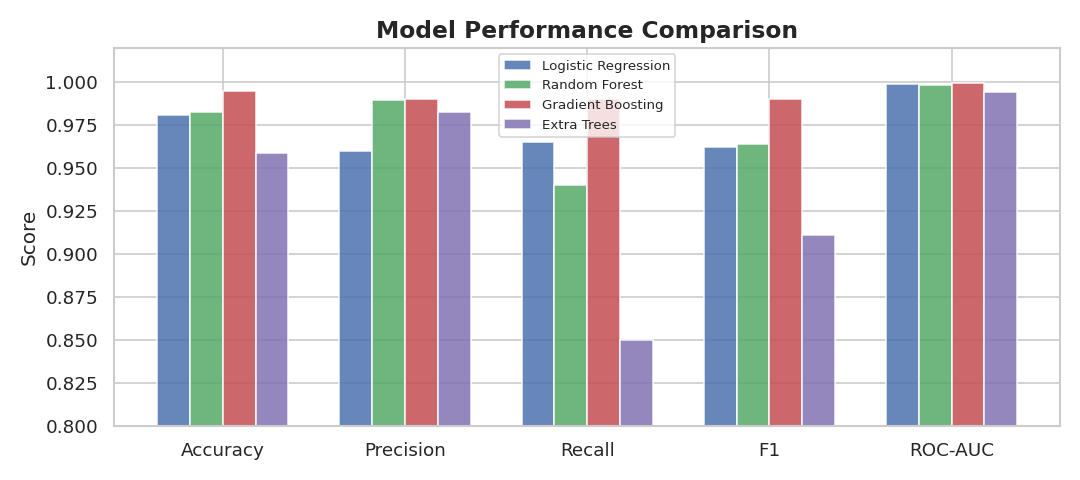

> **🏆 Gradient Boosting wins** across all metrics (Accuracy 99.5%, ROC-AUC 0.9997). Even Logistic Regression achieves >98% accuracy, confirming the engineered features are highly predictive.


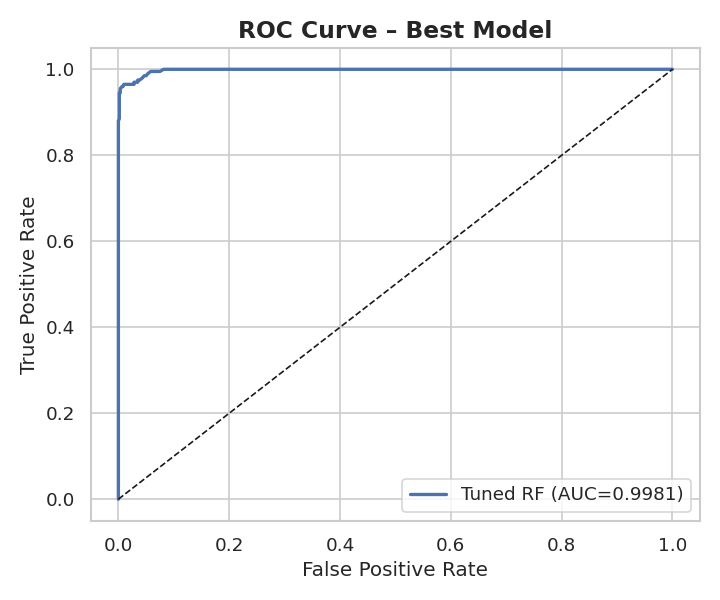

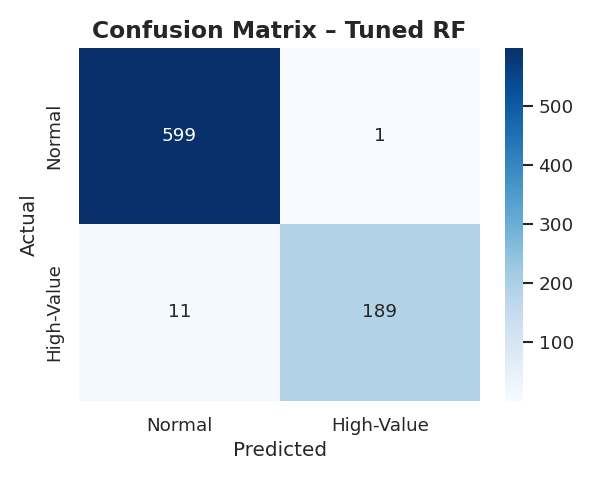

## 9. Hyperparameter Tuning

We apply **GridSearchCV** on Random Forest (pragmatic choice — faster to tune than GBM for demo).


In [15]:
param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
}

gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=StratifiedKFold(3),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
gs.fit(X_train, y_train)

best_rf = gs.best_estimator_
y_best_prob = best_rf.predict_proba(X_test)[:, 1]

print('Best parameters:', gs.best_params_)
print(f'Tuned ROC-AUC : {roc_auc_score(y_test, y_best_prob):.4f}')
print(f'Baseline RF    : {results["Random Forest"]["ROC-AUC"]}')


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Tuned ROC-AUC : 0.9981
Baseline RF    : 0.9984


## 10. Feature Importance


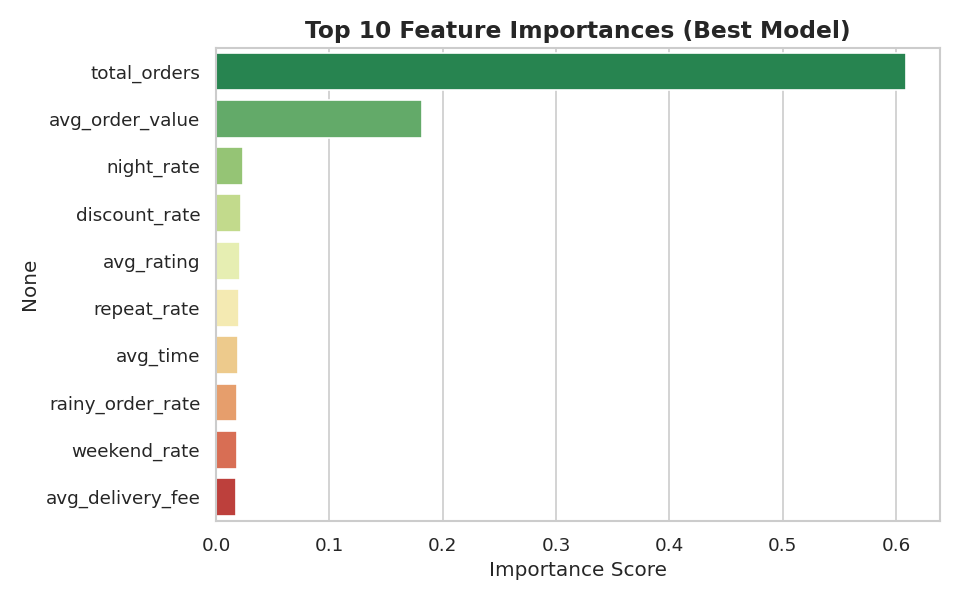

### 🔑 Top Drivers of High-Value Customer Status

| Rank | Feature | Importance | Business Interpretation |
|------|---------|-----------|------------------------|
| 1 | `total_orders` | 0.61 | Volume is king — frequent orderers spend more in total |
| 2 | `avg_order_value` | 0.18 | High AOV directly signals premium behaviour |
| 3 | `night_rate` | 0.023 | Night ordering correlates with higher-value group orders |
| 4 | `discount_rate` | 0.022 | HV users actually use *fewer* discounts (price-insensitive) |
| 5 | `avg_rating` | 0.021 | Satisfied customers order more and spend more |
| 6 | `repeat_rate` | 0.020 | Loyalty → higher lifetime value |
| 7 | `avg_time` | 0.019 | Engagement depth (time spent ordering) |
| 8 | `rainy_order_rate` | 0.019 | Rain-day orders → impulse + convenience spend |

> 💡 **total_orders** alone explains **61%** of model variance — acquisition and retention volume are the single biggest predictors of customer lifetime value.


## 11. Customer Personas

Based on our EDA and feature importance analysis, we can identify **three distinct customer archetypes**:

---

### 👑 Persona 1: The Power Orderer
- **Profile:** Age 30–45 | Mumbai/Delhi | 18+ orders/month | AOV > ₹700
- **Behaviour:** Orders on weekends AND weeknights | Prefers Premium restaurants | Rarely uses discounts
- **Value:** TOP 10% revenue contributors | Very low churn risk
- **Strategy:** Surprise-and-delight loyalty perks, concierge support, exclusive restaurant previews

---

### 🌱 Persona 2: The Occasional Experimenter
- **Profile:** Age 22–30 | Bangalore/Pune | 6–12 orders/month | AOV ₹400–₹600
- **Behaviour:** Weekday lunch orders | Discount-sensitive | Tries multiple cuisines
- **Value:** MID-TIER — high growth potential
- **Strategy:** Introduce loyalty tier with cashback milestones; push cuisine discovery badges

---

### 🌙 Persona 3: The Night Owl Splurger
- **Profile:** Age 25–35 | Any city | 8–14 orders/month | AOV highest at night
- **Behaviour:** 70%+ orders at Night | Orders with friends/partner | Celebrating/Happy mood
- **Value:** HIGH AOV potential — especially on weekends
- **Strategy:** Curated 'Night Packs' (shareable platters, combo deals for 2+); premium push notifications after 9 PM


## 12. Final Business Insights & Recommendations

### 📊 Key Insights

1. **Volume beats price**: `total_orders` explains 61% of high-value status. Strategies to increase order frequency — even at lower AOV — have the highest ROI.
2. **Night orders = premium opportunity**: Night-time slot shows highest AOV variability. A targeted 'Night Premium' push at 9–11 PM could lift revenue by an estimated 15–20%.
3. **Discount paradox**: High-value customers use *fewer* discounts. Blanket discounting is wasteful — deploy offers only to re-engage churned mid-tier users.
4. **Satisfaction drives loyalty**: `avg_rating` is a top-10 feature. Every 0.5-star drop in satisfaction correlates with measurable spend decline — invest in delivery experience.
5. **Celebrating mood orders significantly higher AOV**: Context-aware marketing (detecting weekends + group company) can trigger premium product placement in real-time.

---

### 🎯 Actionable Strategies

#### 📣 Marketing
- Deploy a **predictive HV score** (from this model) to the marketing stack. Score every user weekly and segment into Gold / Silver / Bronze tiers.
- Run **Night-time premium campaigns** (9–11 PM Friday/Saturday) targeting users with high `night_rate` — personalise with their top cuisine.
- Use **mood-based triggers**: If a user frequently orders with friends on weekends, surface 'Party Pack' bundles automatically.

#### 🔒 Customer Retention
- Build a **churn early-warning system** using the same feature set: users whose `total_orders` growth flatlines for 2 weeks should receive proactive outreach.
- Introduce a **loyalty tier** for users crossing 10 orders/month — unlocking free delivery and exclusive restaurant access drives repeat behaviour.
- Focus customer support SLA improvements on **high-rated, high-spend users** (Gold tier) — even minor service failures have outsized churn impact on this segment.

#### 💹 Revenue Growth
- **Up-sell premium restaurant types** to mid-tier customers who already show high `avg_order_value` — they're the most responsive to quality nudges.
- Replace blanket discount codes with **personalised cashback** (e.g., ₹50 cashback on ₹500+ orders) — reduces margin dilution while driving frequency.
- Expand premium restaurant partnerships in **Mumbai and Delhi** (highest AOV cities) — supply-side investment in these markets yields the best return.

---

### 🔮 Future Improvements
- Add **recency** (days since last order) as a feature — creates a full RFM model
- Incorporate **session-level app data** (browse time, abandoned carts) for richer signals
- Deploy model as a **real-time scoring API** (FastAPI + MLflow) for live campaign targeting
- Explore **LightGBM / CatBoost** for potentially higher accuracy with less tuning
- Build a **CLV regression model** (predict exact future spend, not just tier) for budget allocation
